# TEST EMBEDDING COLLAPSE

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, silhouette_samples
from elasticsearch import Elasticsearch, helpers
import os
import json
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
import random
import umap
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
env = "DEV"
MODEL_ID = "intfloat__e5-small-v2"
MODEL_NAME = "e5"
INDEX_NAME_RAW = "pp-vs-e5-llmd-embeddings-newprompt-uat-raw"  # stores documents with vector embeddings
SHOULD_DELETE_INDEX = False
#CLOUD_ID="dsg-search-dev-east:ZWFzdHVzLmF6dXJlLmVsYXN0aWMtY2xvdWQuY29tOjQ0MyQ1Zjc1NDk5MTVmNmE0ZTBjYWFhYzYzM2IwZDI1MjNlZSRiZTg1OWU2ZGM0ZTg0Y2RmYTVjNDNkNzJiZDA3ZTg3Mg=="
ES_HOST = os.getenv("ELASTIC_HOST_DEV")
ES_USER = os.getenv("ELASTIC_USERNAME")
ES_PASS = os.getenv("ELASTIC_PASSWORD")
dims = 384 

In [10]:
es = Elasticsearch(
    ES_HOST,  # Replace with your actual host
    basic_auth=(ES_USER,ES_PASS),
    request_timeout=600,
    verify_certs=True  # Optional: Set to False only if using self-signed certs
)

# Test connection
print(es.info().body)

{'name': 'instance-0000000096', 'cluster_name': '5f7549915f6a4e0caaac633b0d2523ee', 'cluster_uuid': 'hrds7YuPRLy60DbQMfN9Ow', 'version': {'number': '8.19.3', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '1fde05a4d63448377eceb8fd3d51ce16ca3f02a9', 'build_date': '2025-08-26T02:35:34.366492370Z', 'build_snapshot': False, 'lucene_version': '9.12.2', 'minimum_wire_compatibility_version': '7.17.0', 'minimum_index_compatibility_version': '7.0.0'}, 'tagline': 'You Know, for Search'}


In [11]:
def get_embedding_column(model_name: str) -> str:
      return "vs_sbert_embedding" if model_name.lower() == "sbert" else "vs_e5_llm_product_desc_embedding" 

In [12]:
def run_knn_query(es, index_name, model_id, embedding_field, query_text, size=8, num_candidates=None):
    if num_candidates is None:
        num_candidates = max(50 * size, 1000)

    body = {
        "size": size,
        "_source": ["ecode", "product_type", "llm_description", 'title'],  # add fields you need
        "knn": {
            "field": embedding_field,
            "k": size,
            "num_candidates": num_candidates,
            "query_vector_builder": {
                "text_embedding": {
                    "model_id": model_id,
                    "model_text": query_text
                }
            }
        }
    }

    resp = es.search(index=index_name, body=body)

    hits = []
    for h in resp["hits"]["hits"]:
        src = h.get("_source", {})
        hits.append({
            "score": h.get("_score"),
            "ecode": src.get("ecode"),
            "product_type": src.get("product_type"),
            "llm_description": src.get("llm_description"),
        })
    return hits


In [13]:
query_text = f"query: feather coat"
#query_text = "lightweight nike running shoes for men"
#query_text = f"query: feather coat"
# Negative intent (what you DON'T want)
#query_text = "Find: feather coat NOT: featherless NOT: synthetic insulation"

run_knn_query(es,INDEX_NAME_RAW,MODEL_ID,get_embedding_column("e5"),query_text,48)

[{'score': 0.9195016,
  'ecode': '23OBEMWLDRDWNSHRTMOU',
  'product_type': 'Jackets',
  'llm_description': 'passage: Mens outerwear jacket, down insulation with 550 fill power Allied Feather + Down. Heritage design, 100% Polyester Plain Weave HydroBlock Classic. Skiing context. Obermeyer, water-resistant treatment.'},
 {'score': 0.9186541,
  'ecode': '24OBEWWVNTNJCKTXXWOU',
  'product_type': 'Jackets',
  'llm_description': 'passage: Womens outerwear jacket, down-filled insulated construction with 700FP Allied Feather + Down. Adjustable features include 2-way hood, waist, hem, cuffs, and powderskirt. Zipper handwarmer pockets, interior electronics pockets, and integrated carry system. Skiing context.'},
 {'score': 0.916899,
  'ecode': '22TARUVSPR32F0CRGCSL',
  'product_type': 'Blankets',
  'llm_description': 'passage: Unisex outdoor bedding, lightweight quilt blanket. Featherlight construction with thermally-efficient box baffled design, snap neck closure, perimeter side baffles, insula

In [ ]:
def fetch_all_title(es, index_name, source_field='):
    print("Computing μ in streaming mode...")
    count = 0
    mu = None

    for doc in helpers.scan(
        es,
        index=index_name,
        query={"query": {"match_all": {}}, "_source": [source_field]},
        scroll="5m",
        size=500
    ):


In [19]:
def run_knn_query_umap(es, index_name, model_id, embedding_field, query_text, size=8, num_candidates=None):
    if num_candidates is None:
        num_candidates = max(50 * size, 1000)

    body = {
        "size": size,
        "_source": ["ecode", "product_type", "gender", "vs_e5_llm_product_desc_embedding"],  # add fields you need
        "knn": {
            "field": embedding_field,
            "k": size,
            "num_candidates": num_candidates,
            "query_vector_builder": {
                "text_embedding": {
                    "model_id": model_id,
                    "model_text": query_text
                }
            }
        }
    }

    resp = es.search(index=index_name, body=body)

    hits = []
    for h in resp["hits"]["hits"]:
        src = h.get("_source", {})
        hits.append({
            "product_type": src.get("product_type"),
            "gender": src.get("gender"),
            "vs_e5_llm_product_desc_embedding": src.get("vs_e5_llm_product_desc_embedding"),
        })
    return hits


UMAP input shape: (48, 384)


/Users/dks0802651/.pyenv/versions/3.10.13/envs/vector_search_310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


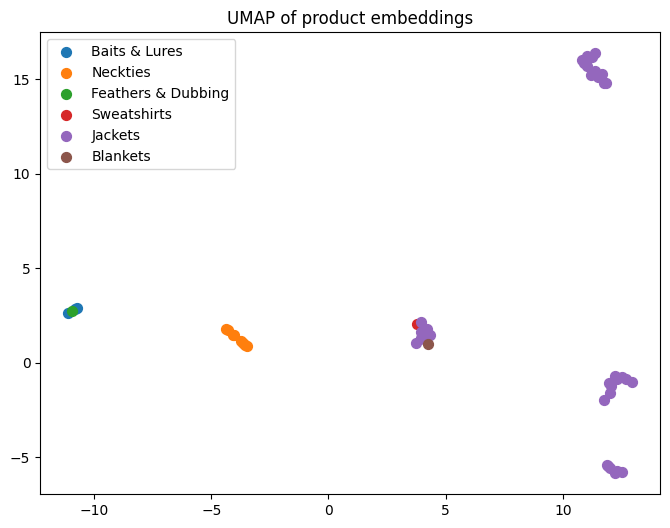

In [15]:
query_text = f"query: feather coat"
hits=run_knn_query_umap(es,INDEX_NAME_RAW,MODEL_ID,get_embedding_column("e5"),query_text,48)
X= []
labels = []

for h in hits:
    emb = h.get("vs_e5_llm_product_desc_embedding")
    if emb is None:
        continue
    if not isinstance(emb, (list, tuple)):
        continue
    if len(emb) == 0:
        continue

    vec = np.asarray(emb, dtype=np.float32)

    if not np.all(np.isfinite(vec)):
        continue

    X.append(vec)
    labels.append(h.get("product_type", "UNKNOWN"))
    
if len(X) < 3:
    raise ValueError(
        f"Not enough valid embeddings for UMAP. "
        f"Got {len(X)} vectors out of {len(hits)} hits."
    )

X = np.vstack(X)

print("UMAP input shape:", X.shape)

reducer = umap.UMAP(
    n_neighbors=min(5, X.shape[0] - 1),
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

Z = reducer.fit_transform(X)

plt.figure(figsize=(8,6))
for t in set(labels):
    idx = [i for i,l in enumerate(labels) if l == t]
    plt.scatter(Z[idx,0], Z[idx,1], label=t, s=50)

plt.legend()
plt.title("UMAP of product embeddings")
plt.savefig("UMAP_of_product_embeddings.png",dpi=300, bbox_inches='tight')

plt.show()


UMAP input shape: (48, 384)


/Users/dks0802651/.pyenv/versions/3.10.13/envs/vector_search_310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


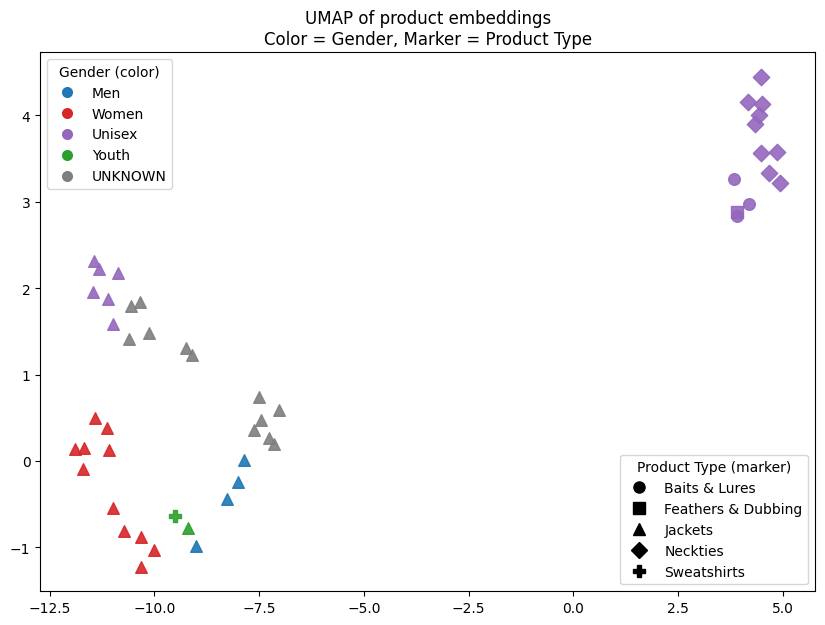

In [25]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

query_text = "query: feather coat"
hits = run_knn_query_umap(
    es,
    INDEX_NAME_RAW,
    MODEL_ID,
    get_embedding_column("e5"),
    query_text,
    48
)

X = []
product_types = []
genders = []

for h in hits:
    emb = h.get("vs_e5_llm_product_desc_embedding")
    if emb is None or not isinstance(emb, (list, tuple)) or len(emb) == 0:
        continue

    vec = np.asarray(emb, dtype=np.float32)
    if vec.ndim != 1 or not np.all(np.isfinite(vec)):
        continue

    X.append(vec)
    product_types.append(h.get("product_type", "UNKNOWN"))
    genders.append(h.get("gender", "UNKNOWN"))

if len(X) < 3:
    raise ValueError(
        f"Not enough valid embeddings for UMAP. "
        f"Got {len(X)} vectors out of {len(hits)} hits."
    )

X = np.vstack(X)
print("UMAP input shape:", X.shape)

reducer = umap.UMAP(
    n_neighbors=min(10, X.shape[0] - 1),
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

Z = reducer.fit_transform(X)

# -------------------------
# Color map for gender
# -------------------------
def norm_gender(g):
    if g is None:
        return "UNKNOWN"
    g = str(g).strip().lower()
    if "women" in g:
        return "Women"
    if "men" in g:
        return "Men"
    if "unisex" in g:
        return "Unisex"
    if "youth" in g or "kid" in g:
        return "Youth"
    return "UNKNOWN"

genders_norm = [norm_gender(g) for g in genders]

gender_colors = {
    "Men": "#1f77b4",      # blue
    "Women": "#d62728",    # red
    "Unisex": "#9467bd",   # purple
    "Youth": "#2ca02c",    # green
    "UNKNOWN": "#7f7f7f"   # gray
}

# -------------------------
# Marker map for product type
# -------------------------
unique_types = sorted(set(product_types))
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
marker_map = {t: marker_cycle[i % len(marker_cycle)] for i, t in enumerate(unique_types)}

plt.figure(figsize=(10, 7))

for pt in unique_types:
    idx = [i for i, p in enumerate(product_types) if p == pt]
    if not idx:
        continue

    for g in set(genders_norm):
        idx2 = [i for i in idx if genders_norm[i] == g]
        if not idx2:
            continue

        plt.scatter(
            Z[idx2, 0],
            Z[idx2, 1],
            c=gender_colors[g],
            marker=marker_map[pt],
            s=70,
            alpha=0.9
        )

# --- Gender legend (colors)
gender_handles = [
    Line2D([0], [0], marker="o", color="w", label=g,
           markerfacecolor=c, markersize=9)
    for g, c in gender_colors.items()
]
legend1 = plt.legend(handles=gender_handles, title="Gender (color)", loc="upper left")

# --- Product type legend (markers)
type_handles = [
    Line2D([0], [0], marker=marker_map[t], color="k",
           linestyle="None", label=t, markersize=8)
    for t in unique_types
]
legend2 = plt.legend(handles=type_handles, title="Product Type (marker)", loc="lower right")

plt.gca().add_artist(legend1)

plt.title("UMAP of product embeddings\nColor = Gender, Marker = Product Type")
plt.savefig("UMAP_of_product_embeddings.png", dpi=300, bbox_inches="tight")
plt.show()


In [31]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=6, metric="cosine").fit(X)
dists, idxs = nn.kneighbors(X)

correct = 0
total = 0
X = np.asarray(X, dtype=np.float32)
for i in range(len(X)):
    for j in idxs[i][1:]:   # skip self
        total += 1
        if labels[i] == labels[j]:
            correct += 1

print("Neighbor purity:", round(correct / total,3))


Neighbor purity: 0.917


/Users/dks0802651/.pyenv/versions/3.10.13/envs/vector_search_310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dks0802651/.pyenv/versions/3.10.13/envs/vector_search_310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dks0802651/.pyenv/versions/3.10.13/envs/vector_search_310/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


How strong is 0.9167?    last time 0.82

With your setup (k=6 → 5 neighbors):

91.7% of nearest neighbors share the same label

That indicates very strong local coherence

This is well above what we usually see unless:

labels are clean

embeddings are well-aligned

or classes are trivially separable

Embeddings preserve local semantic structure

Similar items cluster tightly

k-NN style retrieval is likely to be stable

Recent changes (model / prompt / centering) are working

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
pca.fit(X)

print("Top 5 explained variance:", pca.explained_variance_ratio_[:5])
print("Cumulative top 5:", pca.explained_variance_ratio_[:5].sum())

Top 5 explained variance: [0.23741823 0.16103643 0.09240574 0.08061212 0.04367591]
Cumulative top 5: 0.6151484


In [ ]:
def embed_query(text, add_prefix=True):
    """
    Embed a search query
    Args:
        text: Query text
        add_prefix: Add "query: " prefix (recommended for E5)

    Returns:
        numpy array of shape (embedding_dim,)
    """

    if add_prefix:
        text_to_embed = f"query: {text}"
    else:
        text_to_embed = text

    embedding = self.model.encode(
        text_to_embed,
        convert_to_numpy=True,
        normalize_embeddings=self.normalize_embeddings
    )

    return embedding

In [36]:
###### ============================================================================
# GET EMBEDDINGS FROM ELASTICSEARCH
# ============================================================================

def get_embeddings_from_es(index_name: str, query_text: str, size: int = 5):
    """
    Fetch embeddings and descriptions from Elasticsearch
    """
    search_field = get_embedding_column(MODEL_NAME)
    print(search_field)
    print("size=",size)
    print(query_text)
    knn_query_body = { 
        "size" : size,
        "knn": {
            "field": search_field,
            "k": size,  # Number of nearest neighbors to retrieve
            "num_candidates": max(50 * size, 1000),# Number of candidates to consider during search
            "query_vector_builder": {
                "text_embedding": {
                    "model_id": MODEL_ID,    # deployed SBERT/E5 model
                    "model_text": query_text      # the query text to embed
                }
            }   
        }   
    }   
    embeddings = []
    descriptions = []

    results = es.search(
        index=INDEX_NAME_RAW,
        body=knn_query_body
    )   
    for hit in results['hits']['hits']:
        emb = hit['_source']['vs_e5_llm_product_desc_embedding']
        desc = hit['_source']['llm_description'][8:100]
        
        embeddings.append(emb)
        descriptions.append(desc)
    
    return np.array(embeddings), descriptions

In [42]:
# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

def print_embedding_stats(embeddings, descriptions):
    """
    Print statistics about embeddings
    """
    
    print("=" * 80)
    print("EMBEDDING STATISTICS")
    print("=" * 80)
    
    print(f"\nNumber of embeddings: {len(embeddings)}")
    print(f"Embedding dimensions: {len(embeddings[0])}")
    
    # Norms
    norms = [np.linalg.norm(e) for e in embeddings]
    print(f"\nEmbedding norms:")
    print(f"  Average: {np.mean(norms):.6f}")
    print(f"  Min: {np.min(norms):.6f}")
    print(f"  Max: {np.max(norms):.6f}")
    
    # Pairwise similarities
    similarities = []
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            sim = 1 - cosine(embeddings[i], embeddings[j])
            similarities.append(sim)
    
    print(f"\nPairwise similarities:")
    print(f"  Average: {np.mean(similarities):.6f}")
    print(f"  Min: {np.min(similarities):.6f}")
    print(f"  Max: {np.max(similarities):.6f}")
    
    # Create DataFrame for detailed view
    print(f"\n" + "=" * 80)
    print("PAIRWISE SIMILARITY MATRIX")
    print("=" * 80)
    
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            sim = 1 - cosine(embeddings[i], embeddings[j])
            desc_i = descriptions[i][:35]
            desc_j = descriptions[j][:35]
            print(f"{desc_i:<35} vs {desc_j:<35} = {sim:.6f}")


In [43]:
# ============================================================================
# VISUALIZATION FUNCTION 2: PCA (Faster, more interpretable)
# ============================================================================

def visualize_with_pca(embeddings, descriptions, title="Embeddings Visualization (PCA)"):
    """
    Visualize embeddings using PCA
    Faster than t-SNE, shows variance
    """
    
    print("Computing PCA...")
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 8))
    
    # Plot points
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=100, alpha=0.6, c=range(len(embeddings)), cmap='viridis')
    
    # Add labels
    for i, desc in enumerate(descriptions):
        plt.annotate(desc, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                    fontsize=9, alpha=0.7, xytext=(5, 5), textcoords='offset points')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.colorbar(scatter, label='Document Index')
    plt.tight_layout()
    plt.savefig("pca_plot_new_prompt.png", dpi=300, bbox_inches='tight')
    plt.show()

FETCHING EMBEDDINGS FROM ELASTICSEARCH
vs_e5_llm_product_desc_embedding
size= 48
query: feather coat

✓ Fetched 48 embeddings
EMBEDDING STATISTICS

Number of embeddings: 48
Embedding dimensions: 384

Embedding norms:
  Average: 1.000000
  Min: 1.000000
  Max: 1.000000

Pairwise similarities:
  Average: 0.874185
  Min: 0.758824
  Max: 1.000000

PAIRWISE SIMILARITY MATRIX
 Mens outerwear jacket, down insula vs  Womens outerwear jacket, down-fill = 0.908851
 Mens outerwear jacket, down insula vs  Womens outerwear jacket, lightweig = 0.868729
 Mens outerwear jacket, down insula vs  Womens outerwear jacket, lightweig = 0.876188
 Mens outerwear jacket, down insula vs  Fishing bait accessory, feathered  = 0.799621
 Mens outerwear jacket, down insula vs  Womens outerwear jacket, lightweig = 0.857669
 Mens outerwear jacket, down insula vs  Womens outerwear jacket, lightweig = 0.857104
 Mens outerwear jacket, down insula vs  Adult outerwear jacket, full-zip c = 0.868502
 Mens outerwear jacket, d

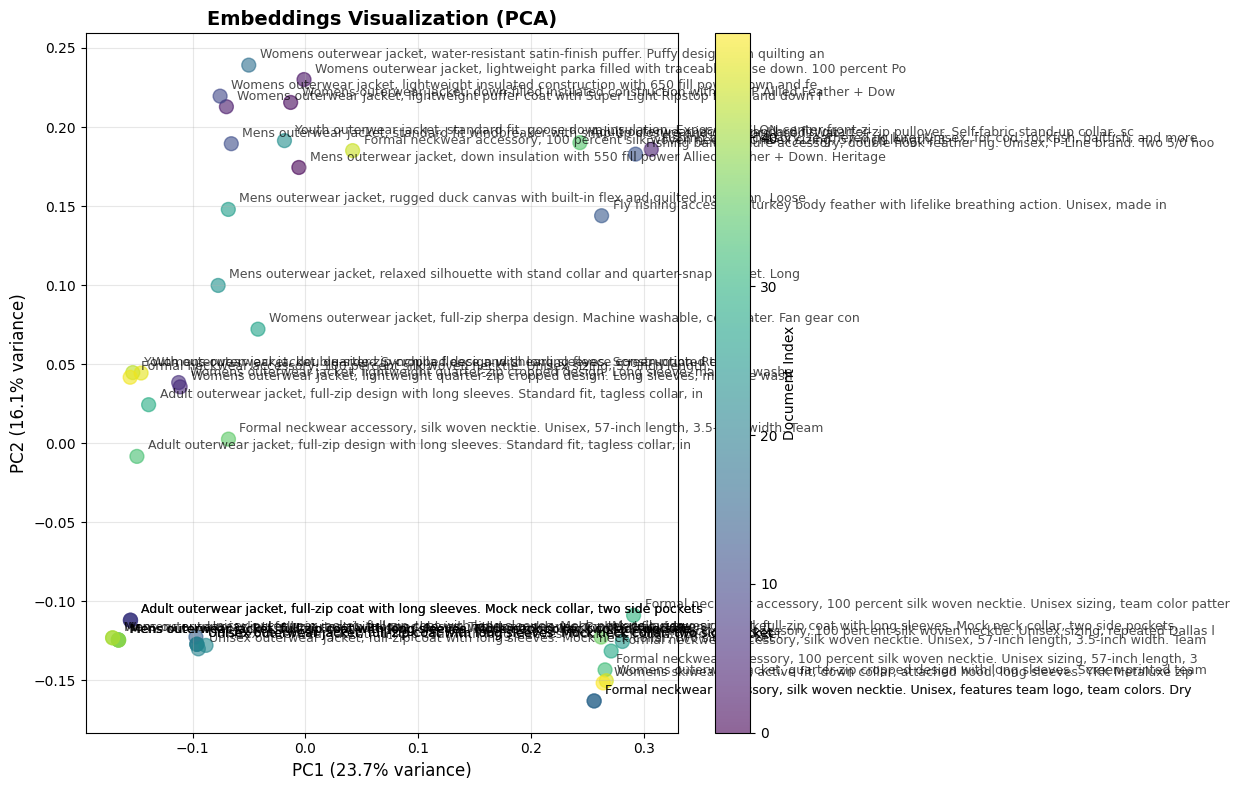

In [46]:

print("=" * 80)
print("FETCHING EMBEDDINGS FROM ELASTICSEARCH")
print("=" * 80)
query_text = f"query: feather coat"
    
# Get embeddings (change num_docs to get more/fewer)
embeddings, descriptions = get_embeddings_from_es(INDEX_NAME_RAW, query_text, size=48)
    
print(f"\n✓ Fetched {len(embeddings)} embeddings")
    
# Print statistics
print_embedding_stats(embeddings, descriptions)

#Visualize with both methods
print("\n" + "=" * 80)
print("VISUALIZATION 1: PCA (Faster)")
print("=" * 80)
visualize_with_pca(X, descriptions)
 

In [27]:
# 
import gradio as gr
import json
from typing import Any, Dict, List

# -------------------------------------------------------------------
# Plug your existing Elasticsearch client + search function here
# -------------------------------------------------------------------
def run_query( query_text: str, size=48): 
    """Run a KNN query against the index"""
    search_field = get_embedding_column(MODEL_NAME)
    query_text = "query: " + query_text
    print(search_field)
    print("size=",size) 
    print(query_text)
    knn_query_body = { 
        "size" : size,
        "knn": {
            "field": search_field,
            "k": size,  # Number of nearest neighbors to retrieve
            "num_candidates": max(50 * size, 1000),# Number of candidates to consider during search
            "query_vector_builder": {
                "text_embedding": {
                    "model_id": MODEL_ID,    # deployed SBERT/E5 model
                    "model_text": query_text      # the query text to embed
                }
            }   
        }   
    }   

    response = es.search(
        index=INDEX_NAME_RAW,
        body=knn_query_body
    )   

    results = [ 
        {   
            "score": hit["_score"],
            "title": hit["_source"].get("llm_description", "N/A"),
            "id": hit.get("_id", "N/A")
        }   
        for hit in response["hits"]["hits"]
    ]   
    return response

# -------------------------------------------------------------------
# Parse ES hits -> display rows
# -------------------------------------------------------------------
def parse_es_results(resp: Dict[str, Any], max_chars: int = 280) -> List[Dict[str, Any]]:
    hits = (resp or {}).get("hits", {}).get("hits", []) or []
    out: List[Dict[str, Any]] = []

    for h in hits:
        src = h.get("_source", {}) or {}
        llm_desc = src.get("llm_description", "") or ""
        llm_desc = llm_desc.replace("\n", " ").strip()
        if len(llm_desc) > max_chars:
            llm_desc = llm_desc[:max_chars] + "..."

        out.append({
            "score": h.get("_score"),
            "ecode": h.get("_id"),
            "llm_description": llm_desc[8:],
        })

    return out


# -------------------------------------------------------------------
# Gradio handler
# -------------------------------------------------------------------
def ui_search(query_text: str) -> str:
    query_text = (query_text or "").strip()
    if not query_text:
        return "<div style='color:#b00020;'>Please enter a search term.</div>"

    try:
        resp = run_query(query_text)
        rows = parse_es_results(resp)

        if not rows:
            return "<div>No results.</div>"

        # Build a scrollable HTML panel
        cards = []
        for r in rows:
            cards.append(f"""
            <div style="
                border:1px solid #e5e7eb;
                border-radius:12px;
                padding:12px 14px;
                margin-bottom:10px;
                background:#ffffff;
            ">
            <div style="margin-top:6px; font-size:13px;">
  <span style="font-weight:600; color:#6B7280;">ecode:</span>
  <span
    style="
      margin-left:4px;
      font-family:ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, 'Liberation Mono', 'Courier New', monospace;
      color:#000000;
      font-weight:700;
    "
  >
    {r.get("ecode", "") or ""}
  </span>
</div>

              <div style="margin-top:8px; font-size:13px; color:#374151; line-height:1.35;">
                {r.get("llm_description","") or ""}
              </div>
            </div>
            """)

        html = f"""
        <div style="
            max-height:520px;
            overflow-y:auto;
            padding-right:6px;
        ">
          {''.join(cards)}
        </div>
        """
        return html

    except Exception as e:
        return f"<div style='color:#b00020;'>Error: {str(e)}</div>"


# -------------------------------------------------------------------
# Gradio UI
# -------------------------------------------------------------------
CSS = """
#app_title {
  font-weight: 800;
  color: #0a8f3c; /* green */
  font-size: 26px;
  margin: 6px 0 14px 0;
}
"""

with gr.Blocks(css=CSS) as demo:
    gr.HTML("<div id='app_title'>Dick's Vector Search Application</div>")

    with gr.Row():
        query_in = gr.Textbox(
            label="Search",
            placeholder="e.g., feather coat, garden shoes, down jacket...",
            lines=1
        )
        search_btn = gr.Button("Search", variant="primary")

    results_html = gr.HTML(value="<div>Enter a query and click Search.</div>")

    # click + enter key
    search_btn.click(fn=ui_search, inputs=query_in, outputs=results_html)
    query_in.submit(fn=ui_search, inputs=query_in, outputs=results_html)

#demo.launch()
demo.launch(server_name="0.0.0.0", server_port=7860)

/var/folders/36/3pkr81w50c72tdrmbywpc2540000gp/T/ipykernel_22427/1535211493.py:142: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=CSS) as demo:


* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.


vs_e5_llm_product_desc_embedding
size= 48
query: faether coat
